## Package Installions Setup

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    AdaBoostRegressor
)

from sklearn.metrics import mean_squared_error

from xgboost import XGBRegressor


train_df = pd.read_csv("listings_train.csv")
test_df = pd.read_csv("listings_test_features.csv")

# EDA

## Question 0 – Problem Framing

What type of machine learning problem is this?

This is a supervised machine-learning problem because the training dataset contains independent variables describing each Airbnb listing and a known dependent variable, price. It is specifically a regression problem because price is a continuous numerical value rather than a category.

## Question 1 – Data Quality

How many columns are there in the training set? How many in the test set? Where do they match / mismatch? Which contain missing values? How many rows are there in the training set? How many in the test set? How many are usable as is?

In [6]:
# Dataset size and row completeness

print("TRAINING DATA")
print("Rows:", train_df.shape[0])
print("Columns:", train_df.shape[1])
print("Complete rows:", train_df.dropna().shape[0])
print(
    "Rows with missing values:",
    train_df.isna().any(axis=1).sum()
)

print("\nTEST DATA")
print("Rows:", test_df.shape[0])
print("Columns:", test_df.shape[1])
print("Complete rows:", test_df.dropna().shape[0])
print(
    "Rows with missing values:",
    test_df.isna().any(axis=1).sum()
)


# Compare columns between training and test datasets

train_columns = set(train_df.columns)
test_columns = set(test_df.columns)

matching_columns = sorted(
    train_columns.intersection(test_columns)
)

train_only_columns = sorted(
    train_columns - test_columns
)

test_only_columns = sorted(
    test_columns - train_columns
)

print("\nCOLUMN COMPARISON")
print("Number of matching columns:", len(matching_columns))

print("\nMatching columns:")
print(matching_columns)

print("\nTraining-only columns:")
print(train_only_columns)

print("\nTest-only columns:")
print(test_only_columns)


# Missing-value counts

train_missing_counts = (
    train_df.isna()
    .sum()
    .loc[lambda values: values > 0]
    .sort_values(ascending=False)
)

test_missing_counts = (
    test_df.isna()
    .sum()
    .loc[lambda values: values > 0]
    .sort_values(ascending=False)
)

print("\nTRAINING COLUMNS WITH MISSING VALUES")
print(train_missing_counts)

print("\nTEST COLUMNS WITH MISSING VALUES")
print(test_missing_counts)


# Missing-value percentages

train_missing_percentages = (
    train_df.isna()
    .mean()
    .mul(100)
    .loc[lambda values: values > 0]
    .sort_values(ascending=False)
    .round(2)
)

test_missing_percentages = (
    test_df.isna()
    .mean()
    .mul(100)
    .loc[lambda values: values > 0]
    .sort_values(ascending=False)
    .round(2)
)

print("\nTRAINING MISSING VALUE PERCENTAGES")
print(train_missing_percentages)

print("\nTEST MISSING VALUE PERCENTAGES")
print(test_missing_percentages)

TRAINING DATA
Rows: 42234
Columns: 36
Complete rows: 0
Rows with missing values: 42234

TEST DATA
Rows: 8199
Columns: 35
Complete rows: 0
Rows with missing values: 8199

COLUMN COMPARISON
Number of matching columns: 35

Matching columns:
['accommodates', 'amenities', 'availability_30', 'availability_365', 'availability_60', 'availability_90', 'bathrooms', 'bedrooms', 'beds', 'calculated_host_listings_count', 'host_has_profile_pic', 'host_id', 'host_identity_verified', 'host_name', 'host_total_listings_count', 'id', 'last_review', 'latitude', 'license', 'longitude', 'minimum_nights', 'name', 'neighbourhood', 'neighbourhood_group', 'number_of_reviews', 'number_of_reviews_ltm', 'review_scores_accuracy', 'review_scores_checkin', 'review_scores_cleanliness', 'review_scores_communication', 'review_scores_location', 'review_scores_rating', 'review_scores_value', 'reviews_per_month', 'room_type']

Training-only columns:
['price']

Test-only columns:
[]

TRAINING COLUMNS WITH MISSING VALUES
lic

### Data Quality

The training dataset contains 42,234 rows and 36 columns, while the test dataset contains 8,199 rows and 35 columns. The datasets share 35 feature columns. The only column present in the training dataset but not in the test dataset is price, which is the target variable that the model will predict.

Both datasets contain NaN (missing) values. In the training dataset, the columns with the most missing values are license, neighbourhood_group, and the review-related columns such as review_scores_value. In the test dataset, license and neighbourhood_group contain missing values. Because license and neighbourhood_group are 100% missing, there are 0 complete rows in either dataset, meaning every row contains at least one missing value.

To prepare the data for modeling, the license and neighbourhood_group columns will be removed because they contain no usable information. For the remaining features, numeric missing values will be imputed using the median, while categorical missing values will be imputed using the most frequent category before applying one-hot encoding. This preserves the available training examples instead of discarding rows with missing values.

## Question 2: Distributions

PRICE DISTRIBUTION
Median price: 141.0
Mean price: 166.24274281384666
Skewness: 1.180650665854797

PRICE SUMMARY STATISTICS
count    42234.000000
mean       166.242743
std         98.380093
min         50.000000
25%         90.000000
50%        141.000000
75%        215.000000
max        500.000000
Name: price, dtype: float64


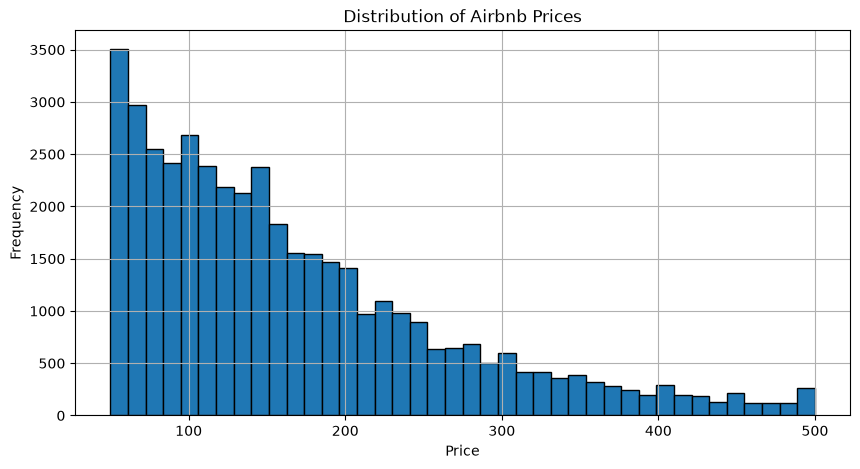


NUMERIC FEATURE COLUMNS
['host_total_listings_count', 'latitude', 'longitude', 'minimum_nights', 'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'availability_30', 'availability_60', 'availability_90', 'number_of_reviews', 'reviews_per_month', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'price']


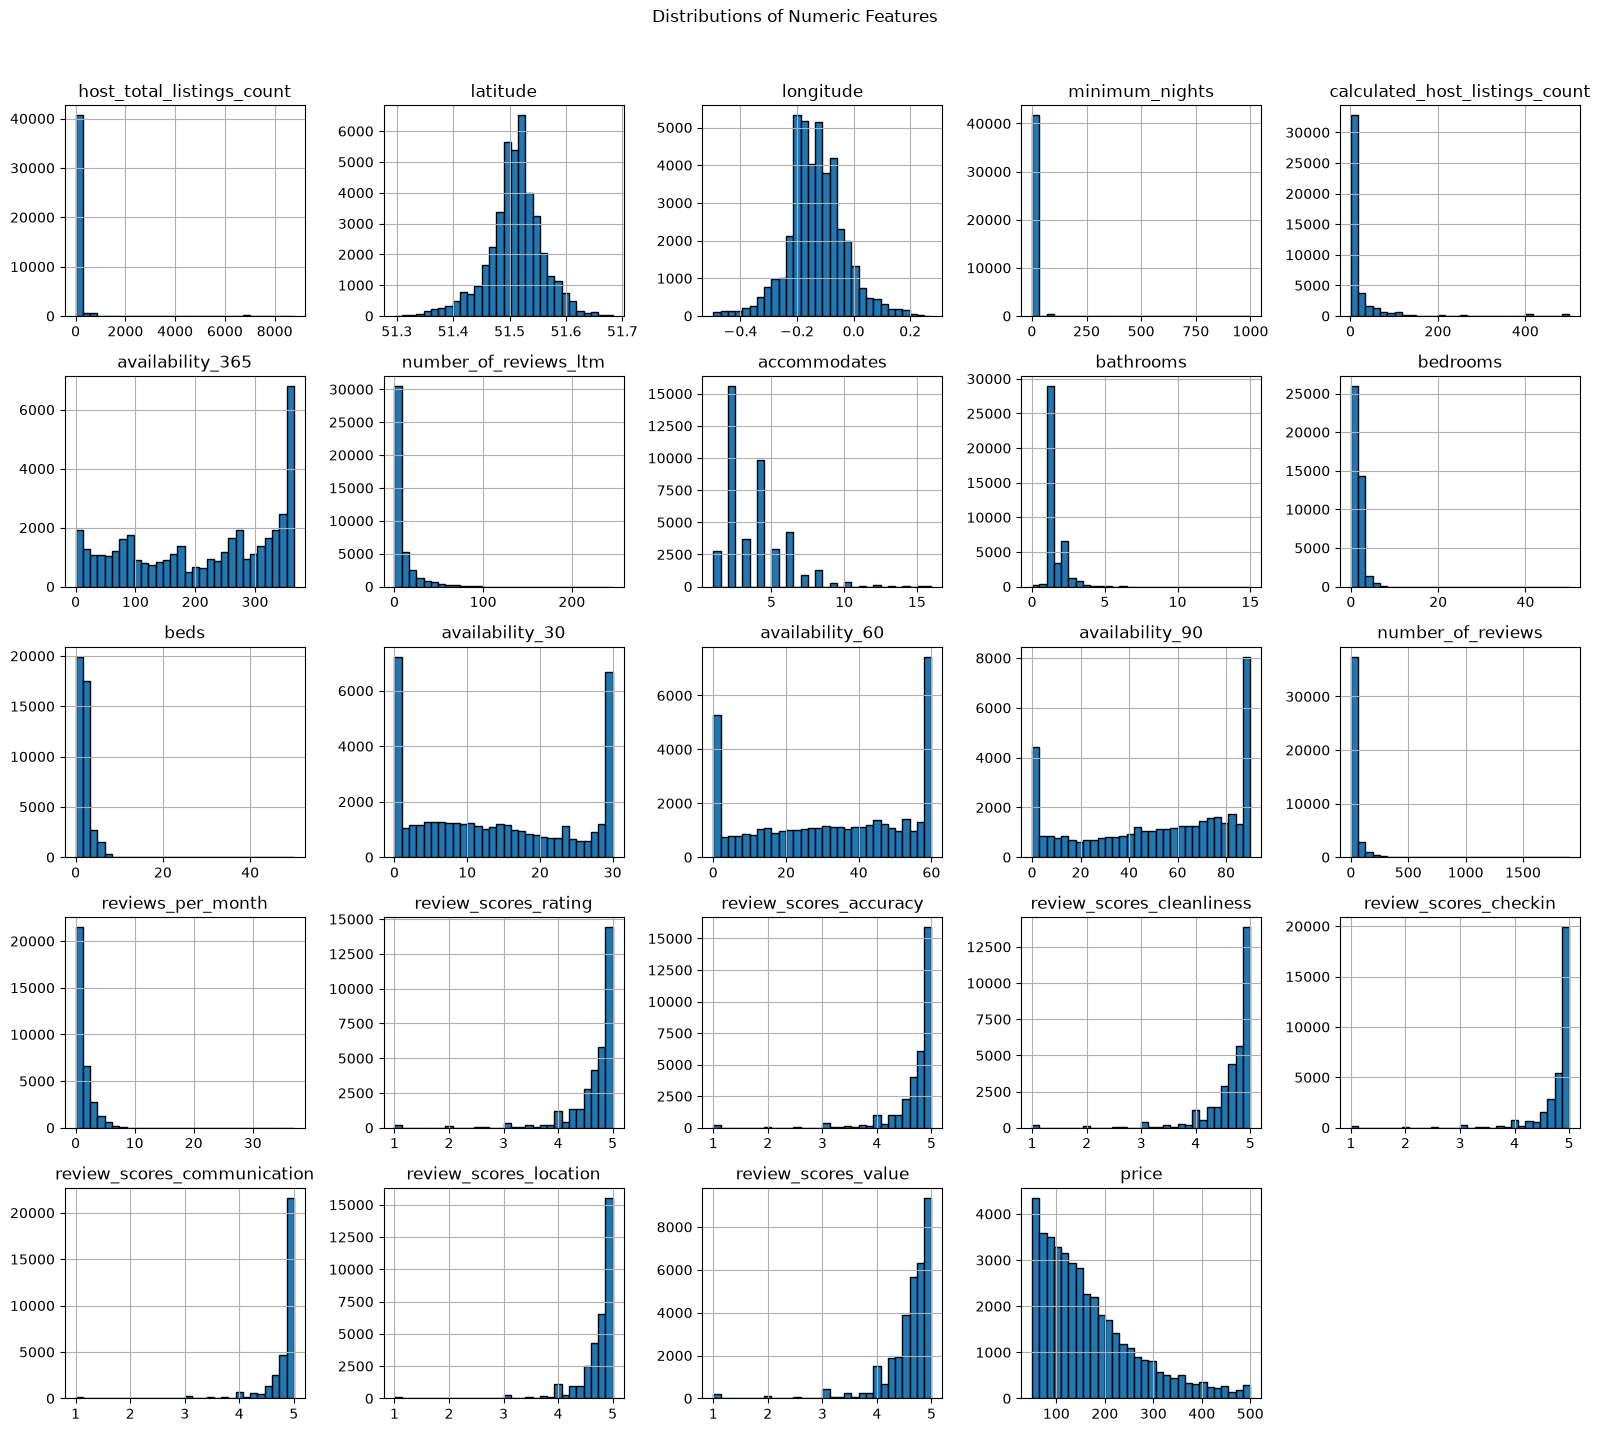


SKEWNESS OF NUMERIC FEATURES
minimum_nights                    16.791109
host_total_listings_count         10.386623
number_of_reviews                  6.569441
calculated_host_listings_count     6.016369
bedrooms                           4.627724
bathrooms                          3.254468
number_of_reviews_ltm              3.200100
beds                               2.905142
reviews_per_month                  2.880422
accommodates                       1.427045
price                              1.180651
availability_30                    0.222241
longitude                          0.108052
availability_60                   -0.183730
availability_365                  -0.285409
latitude                          -0.406620
availability_90                   -0.415099
review_scores_value               -3.429704
review_scores_cleanliness         -3.646035
review_scores_rating              -3.803996
review_scores_accuracy            -4.142297
review_scores_location            -4.381709
re

,column,unique_values,missing_values
0,name,41118,0
6,amenities,38642,0
1,host_name,9090,18
7,last_review,1660,9135
4,neighbourhood,33,0
5,room_type,4,0
2,host_has_profile_pic,2,16
3,host_identity_verified,2,16



PLANNED PREPROCESSING
The license and neighbourhood_group columns will be removed because they contain only missing values.
Numeric missing values will be replaced with the median.
Categorical missing values will be replaced with the most frequent category.
Low-cardinality categorical columns, such as room_type and neighbourhood, will be one-hot encoded.
High-cardinality text columns, such as name, host_name, and amenities, may be removed or handled separately to avoid creating too many encoded columns.
The last_review column should be converted from text to a datetime feature before modeling.


In [7]:
# Price summary
print("PRICE DISTRIBUTION")
print("Median price:", train_df["price"].median())
print("Mean price:", train_df["price"].mean())
print("Skewness:", train_df["price"].skew())

print("\nPRICE SUMMARY STATISTICS")
print(train_df["price"].describe())


# Plot price distribution
plt.figure(figsize=(10, 5))
train_df["price"].hist(
    bins=40,
    edgecolor="black"
)

plt.title("Distribution of Airbnb Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()


# Identify numeric columns
numeric_columns = train_df.select_dtypes(
    include=["number"]
).columns

# Remove columns that contain only missing values
numeric_columns = numeric_columns.drop(
    ["license", "neighbourhood_group"],
    errors="ignore"
)

# Remove identifier columns because their distributions
# are not meaningful for modeling
numeric_feature_columns = numeric_columns.drop(
    ["id", "host_id"],
    errors="ignore"
)

print("\nNUMERIC FEATURE COLUMNS")
print(list(numeric_feature_columns))


# Plot numeric feature distributions
train_df[numeric_feature_columns].hist(
    figsize=(16, 14),
    bins=30,
    edgecolor="black"
)

plt.suptitle(
    "Distributions of Numeric Features",
    y=1.02
)

plt.tight_layout()
plt.show()


# Calculate skewness of numeric features
numeric_skewness = (
    train_df[numeric_feature_columns]
    .skew()
    .sort_values(ascending=False)
)

print("\nSKEWNESS OF NUMERIC FEATURES")
print(numeric_skewness)


# Identify non-numeric columns
non_numeric_columns = train_df.select_dtypes(
    exclude=["number"]
).columns

print(
    "\nNON-NUMERIC COLUMNS AND UNIQUE VALUE COUNTS"
)

for column in non_numeric_columns:
    unique_count = train_df[column].nunique(
        dropna=True
    )

    missing_count = train_df[column].isna().sum()

    print(
        f"{column}: "
        f"{unique_count} unique values, "
        f"{missing_count} missing values"
    )


# Display the information as a table
categorical_summary = []

for column in non_numeric_columns:
    categorical_summary.append(
        {
            "column": column,
            "unique_values": train_df[column].nunique(
                dropna=True
            ),
            "missing_values": train_df[column].isna().sum()
        }
    )

categorical_summary = pd.DataFrame(
    categorical_summary
).sort_values(
    by="unique_values",
    ascending=False
)

print("\nCATEGORICAL COLUMN SUMMARY")
display(categorical_summary)


# Planned preprocessing
print("\nPLANNED PREPROCESSING")

print(
    "The license and neighbourhood_group columns "
    "will be removed because they contain only "
    "missing values."
)

print(
    "Numeric missing values will be replaced "
    "with the median."
)

print(
    "Categorical missing values will be replaced "
    "with the most frequent category."
)

print(
    "Low-cardinality categorical columns, such as "
    "room_type and neighbourhood, will be one-hot encoded."
)

print(
    "High-cardinality text columns, such as name, "
    "host_name, and amenities, may be removed or handled "
    "separately to avoid creating too many encoded columns."
)

print(
    "The last_review column should be converted from text "
    "to a datetime feature before modeling."
)

### Distribution Analysis

The distribution of `price` is **not normally distributed** and is right-skewed, with most listings clustered at lower prices and a small number of expensive listings forming a long right tail. The median nightly price is **141 dollars**, while the mean price is **166.24 dollars**, indicating that higher-priced listings pull the average above the median.

Most numeric features are also not normally distributed. Several variables are strongly right-skewed, including `minimum_nights`, `host_total_listings_count`, and `number_of_reviews`, while review score features are left-skewed because most listings receive high ratings.

The categorical columns contain varying numbers of unique values. For example, `room_type` has **4** unique values, `neighbourhood` has **33**, `host_has_profile_pic` and `host_identity_verified` each have **2**, while `host_name` has **9,090**, `name` has **41,118**, and `amenities` has **38,642** unique values.

Before model training, missing numeric values will be imputed using the median, and missing categorical values will be filled with the most frequent category. Low-cardinality categorical variables such as `room_type`, `neighbourhood`, `host_has_profile_pic`, and `host_identity_verified` will be one-hot encoded. High-cardinality columns such as `name`, `host_name`, and `amenities` may be removed or handled separately because one-hot encoding would create a very large number of sparse features. The `license` and `neighbourhood_group` columns will also be removed because they contain only missing values.

# Data cleansing / Feature Engineering

## Create copies and drop columns

In [8]:
# =========================================================
# Data Cleaning: Copy Data and Drop Unusable Columns
# =========================================================

# Create working copies so the original dataframes remain unchanged
train_clean = train_df.copy()
test_clean = test_df.copy()

# Remove unusable columns, identifiers, and very high-cardinality text
columns_to_drop = [
    "license",
    "neighbourhood_group",
    "id",
    "host_id",
    "name",
    "host_name",
    "amenities"
]

train_clean = train_clean.drop(
    columns=columns_to_drop,
    errors="ignore"
)

test_clean = test_clean.drop(
    columns=columns_to_drop,
    errors="ignore"
)

## Verify shapes and remaining columns

In [9]:
# =========================================================
# Data Cleaning: Verify Remaining Columns
# =========================================================

print("=== Training Dataset After Dropping Columns ===")
print("Shape:", train_clean.shape)
print("Remaining columns:")
print(train_clean.columns.tolist())

print("\n=== Test Dataset After Dropping Columns ===")
print("Shape:", test_clean.shape)
print("Remaining columns:")
print(test_clean.columns.tolist())

=== Training Dataset After Dropping Columns ===
Shape: (42234, 29)
Remaining columns:
['host_total_listings_count', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'minimum_nights', 'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'availability_30', 'availability_60', 'availability_90', 'number_of_reviews', 'last_review', 'reviews_per_month', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'price']

=== Test Dataset After Dropping Columns ===
Shape: (8199, 28)
Remaining columns:
['host_total_listings_count', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'minimum_nights', 'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm', 'accommodate

## Check missing values

In [10]:
# =========================================================
# Data Cleaning: Check Missing Values
# =========================================================

train_missing = (
    train_clean
    .isna()
    .sum()
)

train_missing = (
    train_missing[train_missing > 0]
    .sort_values(ascending=False)
)

test_missing = (
    test_clean
    .isna()
    .sum()
)

test_missing = (
    test_missing[test_missing > 0]
    .sort_values(ascending=False)
)

print("=== Missing Values in Training Dataset ===")

if train_missing.empty:
    print("No missing values found.")
else:
    print(train_missing)

print("\n=== Missing Values in Test Dataset ===")

if test_missing.empty:
    print("No missing values found.")
else:
    print(test_missing)

=== Missing Values in Training Dataset ===
review_scores_checkin          9137
review_scores_location         9137
review_scores_value            9137
review_scores_accuracy         9136
review_scores_cleanliness      9136
review_scores_communication    9136
last_review                    9135
reviews_per_month              9135
review_scores_rating           9135
beds                             80
bedrooms                         47
bathrooms                        42
host_total_listings_count        16
host_has_profile_pic             16
host_identity_verified           16
dtype: int64

=== Missing Values in Test Dataset ===
No missing values found.


## Engineer date features

In [11]:
# =========================================================
# Feature Engineering: Convert Last Review Date
# =========================================================

train_clean["last_review"] = pd.to_datetime(
    train_clean["last_review"],
    errors="coerce"
)

test_clean["last_review"] = pd.to_datetime(
    test_clean["last_review"],
    errors="coerce"
)

# Extract useful numeric features from the date
train_clean["last_review_year"] = (
    train_clean["last_review"].dt.year
)

train_clean["last_review_month"] = (
    train_clean["last_review"].dt.month
)

test_clean["last_review_year"] = (
    test_clean["last_review"].dt.year
)

test_clean["last_review_month"] = (
    test_clean["last_review"].dt.month
)

# Record whether a listing has a recorded review date
train_clean["has_last_review"] = (
    train_clean["last_review"]
    .notna()
    .astype(int)
)

test_clean["has_last_review"] = (
    test_clean["last_review"]
    .notna()
    .astype(int)
)

# Remove the original date column
train_clean = train_clean.drop(
    columns=["last_review"]
)

test_clean = test_clean.drop(
    columns=["last_review"]
)

print("=== Date Feature Engineering Complete ===")
print("Added columns:")
print([
    "last_review_year",
    "last_review_month",
    "has_last_review"
])

print("\nTraining shape:", train_clean.shape)
print("Test shape:", test_clean.shape)

=== Date Feature Engineering Complete ===
Added columns:
['last_review_year', 'last_review_month', 'has_last_review']

Training shape: (42234, 31)
Test shape: (8199, 30)


## Identify numeric and categorical features

In [12]:
# =========================================================
# Feature Engineering: Identify Feature Types
# =========================================================

numeric_feature_columns = (
    train_clean
    .drop(columns=["price"], errors="ignore")
    .select_dtypes(include=["number"])
    .columns
    .tolist()
)

categorical_feature_columns = (
    train_clean
    .drop(columns=["price"], errors="ignore")
    .select_dtypes(
        include=["object", "string", "category"]
    )
    .columns
    .tolist()
)

print("=== Numeric Feature Columns ===")
print(numeric_feature_columns)
print("Count:", len(numeric_feature_columns))

print("\n=== Categorical Feature Columns ===")
print(categorical_feature_columns)
print("Count:", len(categorical_feature_columns))

=== Numeric Feature Columns ===
['host_total_listings_count', 'latitude', 'longitude', 'minimum_nights', 'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'availability_30', 'availability_60', 'availability_90', 'number_of_reviews', 'reviews_per_month', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'last_review_year', 'last_review_month', 'has_last_review']
Count: 26

=== Categorical Feature Columns ===
['host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'room_type']
Count: 4


# Model preparation

In [13]:
# =========================================================
# Model Preparation
# =========================================================

# ---------------------------------------------------------
# Separate the training features from the target
# ---------------------------------------------------------

X = train_clean.drop(columns=["price"])
y = train_clean["price"]

# The test dataset does not contain the target column
X_test = test_clean.copy()


# ---------------------------------------------------------
# Verify that training and test features match
# ---------------------------------------------------------

print("=== Feature Shapes ===")
print("Training features shape:", X.shape)
print("Test features shape:", X_test.shape)

training_only_columns = sorted(
    set(X.columns) - set(X_test.columns)
)

test_only_columns = sorted(
    set(X_test.columns) - set(X.columns)
)

if not training_only_columns and not test_only_columns:
    print("\nTraining and test feature columns match.")
else:
    print("\nTraining-only columns:")
    print(training_only_columns)

    print("\nTest-only columns:")
    print(test_only_columns)


# ---------------------------------------------------------
# Identify numeric and categorical feature columns
# ---------------------------------------------------------

numeric_feature_columns = (
    X
    .select_dtypes(include=["number"])
    .columns
    .tolist()
)

categorical_feature_columns = (
    X
    .select_dtypes(
        include=["object", "string", "category", "bool"]
    )
    .columns
    .tolist()
)

print("\n=== Feature Types ===")
print(
    "Number of numeric features:",
    len(numeric_feature_columns)
)

print(
    "Number of categorical features:",
    len(categorical_feature_columns)
)

print("\nNumeric feature columns:")
print(numeric_feature_columns)

print("\nCategorical feature columns:")
print(categorical_feature_columns)


# ---------------------------------------------------------
# Split the labeled training data
# ---------------------------------------------------------

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\n=== Training and Validation Split ===")
print("Training rows:", len(X_train))
print("Validation rows:", len(X_valid))
print("Training target rows:", len(y_train))
print("Validation target rows:", len(y_valid))


# ---------------------------------------------------------
# Define numeric preprocessing
# ---------------------------------------------------------

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)


# ---------------------------------------------------------
# Define categorical preprocessing
# ---------------------------------------------------------

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


# ---------------------------------------------------------
# Combine preprocessing steps
# ---------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_feature_columns
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_feature_columns
        )
    ]
)


# ---------------------------------------------------------
# Final preparation checks
# ---------------------------------------------------------

print("\n=== Model Preparation Complete ===")
print(
    "Numeric missing values will be filled "
    "with the median."
)

print(
    "Categorical missing values will be filled "
    "with the most frequent value."
)

print(
    "Categorical features will be one-hot encoded."
)

print(
    "All preprocessing will be learned from the "
    "training data when each model pipeline is fitted."
)

=== Feature Shapes ===
Training features shape: (42234, 30)
Test features shape: (8199, 30)

Training and test feature columns match.

=== Feature Types ===
Number of numeric features: 26
Number of categorical features: 4

Numeric feature columns:
['host_total_listings_count', 'latitude', 'longitude', 'minimum_nights', 'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'availability_30', 'availability_60', 'availability_90', 'number_of_reviews', 'reviews_per_month', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'last_review_year', 'last_review_month', 'has_last_review']

Categorical feature columns:
['host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'room_type']

=== Training and Validation Split ===
Training rows: 33787
Validation rows: 8447
Training target

# Model

In [14]:
# =========================================================
# Model
# =========================================================

# Store every model's results
model_results = []


def evaluate_model(model_name, model_pipeline):
    """
    Fit a model pipeline, calculate validation RMSE,
    and save the model and its results.
    """

    model_pipeline.fit(X_train, y_train)

    validation_predictions = model_pipeline.predict(X_valid)

    validation_rmse = np.sqrt(
        mean_squared_error(
            y_valid,
            validation_predictions
        )
    )

    model_results.append({
        "Model": model_name,
        "Validation RMSE": validation_rmse,
        "Pipeline": model_pipeline
    })

    print(
        f"{model_name} Validation RMSE: "
        f"{validation_rmse:.6f}"
    )

    return validation_rmse


# ---------------------------------------------------------
# Model 1: Linear Regression
# ---------------------------------------------------------

linear_regression_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_rmse = evaluate_model(
    "Linear Regression",
    linear_regression_pipeline
)


# ---------------------------------------------------------
# Model 2: Default Decision Tree
# ---------------------------------------------------------

default_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeRegressor(
                random_state=42
            )
        )
    ]
)

default_tree_rmse = evaluate_model(
    "Default Decision Tree",
    default_tree_pipeline
)


# ---------------------------------------------------------
# Model 3: Tune Decision Tree
# ---------------------------------------------------------

tree_tuning_results = []

tree_depths = [
    3,
    5,
    7,
    10,
    15,
    20,
    None
]

tree_leaf_sizes = [
    1,
    2,
    5,
    10,
    20
]

best_tree_pipeline = None
best_tree_rmse = np.inf
best_tree_parameters = None

for max_depth in tree_depths:
    for min_samples_leaf in tree_leaf_sizes:

        candidate_tree_pipeline = Pipeline(
            steps=[
                ("preprocessor", preprocessor),
                (
                    "model",
                    DecisionTreeRegressor(
                        max_depth=max_depth,
                        min_samples_leaf=min_samples_leaf,
                        random_state=42
                    )
                )
            ]
        )

        candidate_tree_pipeline.fit(
            X_train,
            y_train
        )

        candidate_predictions = (
            candidate_tree_pipeline.predict(X_valid)
        )

        candidate_rmse = np.sqrt(
            mean_squared_error(
                y_valid,
                candidate_predictions
            )
        )

        tree_tuning_results.append({
            "max_depth": max_depth,
            "min_samples_leaf": min_samples_leaf,
            "Validation RMSE": candidate_rmse
        })

        if candidate_rmse < best_tree_rmse:
            best_tree_rmse = candidate_rmse
            best_tree_pipeline = candidate_tree_pipeline

            best_tree_parameters = {
                "max_depth": max_depth,
                "min_samples_leaf": min_samples_leaf
            }


tree_tuning_results = (
    pd.DataFrame(tree_tuning_results)
    .sort_values("Validation RMSE")
    .reset_index(drop=True)
)

print("\n=== Best Tuned Decision Tree Parameters ===")
print(best_tree_parameters)

print(
    "Best Tuned Decision Tree Validation RMSE:",
    best_tree_rmse
)

print("\n=== Top Decision Tree Configurations ===")
print(tree_tuning_results.head(10))


model_results.append({
    "Model": (
        "Tuned Decision Tree "
        f"(depth={best_tree_parameters['max_depth']}, "
        f"leaf={best_tree_parameters['min_samples_leaf']})"
    ),
    "Validation RMSE": best_tree_rmse,
    "Pipeline": best_tree_pipeline
})


# ---------------------------------------------------------
# Model 4: Random Forest
# ---------------------------------------------------------

random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                max_depth=None,
                min_samples_leaf=2,
                max_features="sqrt",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_rmse = evaluate_model(
    "Random Forest",
    random_forest_pipeline
)


# ---------------------------------------------------------
# Model 5: AdaBoost
# ---------------------------------------------------------

adaboost_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            AdaBoostRegressor(
                estimator=DecisionTreeRegressor(
                    max_depth=5,
                    min_samples_leaf=5,
                    random_state=42
                ),
                n_estimators=300,
                learning_rate=0.03,
                loss="square",
                random_state=42
            )
        )
    ]
)

adaboost_rmse = evaluate_model(
    "AdaBoost",
    adaboost_pipeline
)


# ---------------------------------------------------------
# Model 6: XGBoost
# ---------------------------------------------------------

xgboost_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBRegressor(
                objective="reg:squarederror",
                n_estimators=600,
                learning_rate=0.03,
                max_depth=6,
                min_child_weight=3,
                subsample=0.80,
                colsample_bytree=0.80,
                reg_alpha=0.05,
                reg_lambda=1.0,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

xgboost_rmse = evaluate_model(
    "XGBoost",
    xgboost_pipeline
)


# ---------------------------------------------------------
# Compare all models
# ---------------------------------------------------------

comparison = (
    pd.DataFrame(model_results)
    .drop(columns=["Pipeline"])
    .sort_values("Validation RMSE")
    .reset_index(drop=True)
)

print("\n========================================")
print("MODEL COMPARISON")
print("========================================")
print(comparison)


# ---------------------------------------------------------
# Select the best model automatically
# ---------------------------------------------------------

best_result = min(
    model_results,
    key=lambda result: result["Validation RMSE"]
)

best_model = best_result["Pipeline"]
best_model_name = best_result["Model"]
best_validation_rmse = best_result["Validation RMSE"]

print("\n========================================")
print("BEST MODEL")
print("========================================")
print("Model:", best_model_name)
print(
    "Validation RMSE:",
    best_validation_rmse
)

Linear Regression Validation RMSE: 66.178190
Default Decision Tree Validation RMSE: 81.394747

=== Best Tuned Decision Tree Parameters ===
{'max_depth': 15, 'min_samples_leaf': 20}
Best Tuned Decision Tree Validation RMSE: 64.9728681230074

=== Top Decision Tree Configurations ===
   max_depth  min_samples_leaf  Validation RMSE
0       15.0                20        64.972868
1       20.0                20        65.311973
2        NaN                20        65.348958
3       10.0                20        65.690881
4       10.0                10        66.112613
5       15.0                10        66.150739
6       10.0                 5        66.370439
7       10.0                 2        66.887194
8        7.0                10        67.381294
9        7.0                20        67.405047
Random Forest Validation RMSE: 57.437725
AdaBoost Validation RMSE: 74.882674
XGBoost Validation RMSE: 53.972457

MODEL COMPARISON
                                     Model  Validation RMSE


In [17]:
# =========================================================
# Train the best model using all labeled training data
# =========================================================

best_model.fit(X, y)

test_predictions = best_model.predict(X_test)

submission = pd.DataFrame({
    "price": test_predictions
})

submission.to_csv(
    "A4_predictions_SrikarDevesetti.csv",
    index=False
)

print("\n=== Submission Preview ===")
print(submission.head())

print("\nPrediction count:", len(submission))
print("Expected count:", len(X_test))
print("Missing predictions:", submission["price"].isna().sum())

print("\nSaved predictions to A4_predictions_SrikarDevesetti.csv")


=== Submission Preview ===
        price
0  228.517639
1  137.156387
2  206.846008
3  251.012985
4  258.767212

Prediction count: 8199
Expected count: 8199
Missing predictions: 0

Saved predictions to A4_predictions_SrikarDevesetti.csv


## Model Explanations

This assignment permits algorithms beyond those covered in class as long as their behavior can be explained. I compared Linear Regression, a default Decision Tree, a tuned Decision Tree, Random Forest, AdaBoost, and XGBoost using validation RMSE.

### Tuned Decision Tree

A Decision Tree predicts price by repeatedly splitting the data into smaller groups based on feature values. For example, the tree may first split listings by room type, then by neighborhood, number of bedrooms, or number of guests.

A default tree can grow too deep and memorize the training data, which causes overfitting. I tuned the following parameters to control the tree's complexity:

- **`max_depth`** limits the maximum number of levels in the tree. A smaller depth produces a simpler model, while a larger depth allows more detailed patterns.
- **`min_samples_leaf`** sets the minimum number of training rows required in each final leaf. Larger values prevent the tree from creating leaves based on very small groups of listings.

I tested multiple combinations of these parameters and selected the combination with the lowest validation RMSE. The validation data, rather than the test features file, was used for model selection.

### Random Forest

Random Forest combines many Decision Trees rather than relying on a single tree. Each tree is trained using a random sample of the training rows and a random subset of the available features.

The final regression prediction is the average of the predictions produced by all of the trees. Averaging many different trees reduces the effect of mistakes made by any single tree and usually reduces overfitting.

Important parameters include:

- **`n_estimators`** controls the number of trees in the forest.
- **`max_depth`** limits the depth of each tree.
- **`min_samples_leaf`** prevents leaves from being based on very small groups.
- **`max_features`** controls how many features each tree considers when making splits.

Random Forest is useful for this dataset because Airbnb price may depend on nonlinear relationships and interactions among neighborhood, room type, capacity, bedrooms, reviews, and availability.

### AdaBoost

AdaBoost builds a sequence of relatively small Decision Trees. Each new tree focuses more heavily on training examples that the earlier trees predicted poorly.

For regression, the model combines the predictions from all of the weak trees into a stronger final prediction. Trees that perform better receive more influence in the combined result.

Important parameters include:

- **`estimator`** defines the base Decision Tree used by AdaBoost.
- **`n_estimators`** controls the number of sequential weak learners.
- **`learning_rate`** controls how strongly each new learner affects the final prediction.
- **`loss`** determines how prediction errors are measured when updating the model.

AdaBoost may improve on a single Decision Tree because later trees concentrate on listings whose prices were difficult for earlier trees to predict. However, it can also be sensitive to unusual listings or outliers because those observations may receive increased attention.

### XGBoost

XGBoost, or Extreme Gradient Boosting, also builds Decision Trees sequentially. Each new tree is trained to reduce the remaining prediction error from the current model.

In regression, the remaining error can be viewed as the difference between the actual price and the current predicted price. Each additional tree makes a small correction, and the final prediction is the sum of the initial prediction and all later corrections.

XGBoost includes several controls that help reduce overfitting:

- **`n_estimators`** controls the number of boosting trees.
- **`learning_rate`** controls the size of each tree's contribution.
- **`max_depth`** limits the complexity of each tree.
- **`min_child_weight`** discourages splits based on very small groups.
- **`subsample`** trains each tree using only a fraction of the training rows.
- **`colsample_bytree`** allows each tree to use only a fraction of the available features.
- **`reg_alpha`** applies L1 regularization.
- **`reg_lambda`** applies L2 regularization.

XGBoost is useful for this Airbnb dataset because listing prices may depend on complex, nonlinear relationships and interactions that Linear Regression may not represent well.

## Model Selection

All models were trained using the same training split and evaluated on the same validation split. I calculated RMSE for each model and selected the model with the lowest validation RMSE. The separate test features file was not used for tuning or model selection.